Hola **Jean**!

Soy **Patricio Requena** 👋. Es un placer ser el revisor de tu proyecto el día de hoy!

Revisaré tu proyecto detenidamente con el objetivo de ayudarte a mejorar y perfeccionar tus habilidades. Durante mi revisión, identificaré áreas donde puedas hacer mejoras en tu código, señalando específicamente qué y cómo podrías ajustar para optimizar el rendimiento y la claridad de tu proyecto. Además, es importante para mí destacar los aspectos que has manejado excepcionalmente bien. Reconocer tus fortalezas te ayudará a entender qué técnicas y métodos están funcionando a tu favor y cómo puedes aplicarlos en futuras tareas. 

_**Recuerda que al final de este notebook encontrarás un comentario general de mi parte**_, empecemos!

Encontrarás mis comentarios dentro de cajas verdes, amarillas o rojas, ⚠️ **por favor, no muevas, modifiques o borres mis comentarios** ⚠️:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si todo está perfecto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si de pronto hace falta algo o existe algún problema con tu código o conclusiones.
</div>

Puedes responderme de esta forma:
<div class="alert alert-block alert-info">
    <b>Respuesta:</b> 

<div class="alert alert-block alert-warning">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Para una correcta presentación de tus proyectos siempre intenta dejar al inicio una celda markdown con un título descriptivo del proyecto y una breve introducción al mismo.
</div>

En el presente proyecto se realizara el analisis de  la cadena de gimnacios Model Fitness con el objetivo de conocer la cancelacion de la membresia y predecir el abandono con un modelo de Machine Learning, estudiar el modelo de prediccion y escoger el tamaño de los clusters y el modelo mas optimo.

Primeramente se importaran las librerias necesarias, luego se revisaran si hay datos duplicados, ausentes y otras acciones para limpiar los datos con el objetivo de tener datos de calidad. 



In [110]:
# importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster



In [111]:
#dataset
df_gym = pd.read_csv('/datasets/gym_churn_us.csv')

In [112]:
def ver_daños(df):
    print(df.isna().sum())
    print('Hay',df.duplicated().sum(), 'duplicados')
    print(df.info())

ver_daños(df_gym)

gender                               0
Near_Location                        0
Partner                              0
Promo_friends                        0
Phone                                0
Contract_period                      0
Group_visits                         0
Age                                  0
Avg_additional_charges_total         0
Month_to_end_contract                0
Lifetime                             0
Avg_class_frequency_total            0
Avg_class_frequency_current_month    0
Churn                                0
dtype: int64
Hay 0 duplicados
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64

In [113]:
df_gym.describe()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,0.510250,0.845250,0.486750,0.308500,0.903500,4.681250,0.412250,29.184250,146.943728,4.322750,3.724750,1.879020,1.767052,0.265250
std,0.499957,0.361711,0.499887,0.461932,0.295313,4.549706,0.492301,3.258367,96.355602,4.191297,3.749267,0.972245,1.052906,0.441521
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,18.000000,0.148205,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,27.000000,68.868830,1.000000,1.000000,1.180875,0.963003,0.000000
50%,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,29.000000,136.220159,1.000000,3.000000,1.832768,1.719574,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000,1.000000,31.000000,210.949625,6.000000,5.000000,2.536078,2.510336,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,1.000000,41.000000,552.590740,12.000000,31.000000,6.023668,6.146783,1.000000


In [114]:
df_gym.groupby('Churn').mean()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month
Churn,,,,,,,,,,,,,
0,0.510037,0.873086,0.534195,0.353522,0.903709,5.747193,0.464103,29.976523,158.445715,5.283089,4.711807,2.024876,2.027882
1,0.510839,0.768143,0.355325,0.183789,0.902922,1.728558,0.268615,26.989632,115.082899,1.662582,0.990575,1.474995,1.044546


<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Correcto, analizaste muy bien de manera inicial los datos con lo que trabajarás
</div>

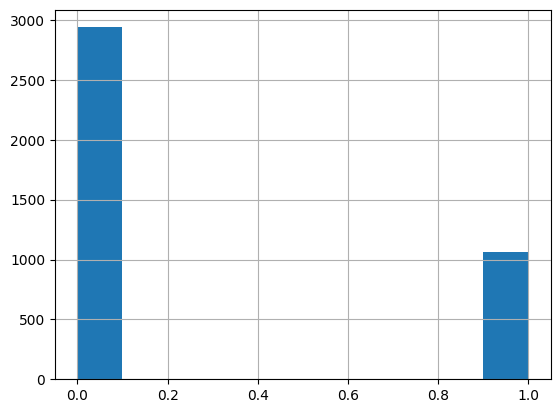

In [115]:
df_gym['Churn'].hist()
plt.show()

In [116]:
abandonaron = df_gym[df_gym['Churn'] == 1].copy()
no_abandonaron = df_gym[df_gym['Churn'] == 0].copy()

In [117]:
print(f"Total clientes: {len(df_gym):,}")
print(f"Clientes que abandonaron: {len(abandonaron):,} ({len(abandonaron)/len(df_gym)*100:.1f}%)")
print(f"Clientes que NO abandonaron: {len(no_abandonaron):,} ({len(no_abandonaron)/len(df_gym)*100:.1f}%)")

Total clientes: 4,000
Clientes que abandonaron: 1,061 (26.5%)
Clientes que NO abandonaron: 2,939 (73.5%)


In [118]:
print(abandonaron)
no_abandonaron

      gender  Near_Location  Partner  Promo_friends  Phone  Contract_period  \
7          0              1        0              0      1                1   
11         1              1        1              0      1                1   
13         1              1        0              0      1                1   
21         0              0        0              0      1                1   
23         1              1        0              0      1                1   
...      ...            ...      ...            ...    ...              ...   
3982       1              1        0              0      1                1   
3984       1              1        0              0      1                6   
3986       0              1        1              1      1                1   
3994       1              1        0              0      1                1   
3996       0              1        0              0      1                1   

      Group_visits  Age  Avg_additional_charges_tot

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3993,0,1,1,0,1,1,0,33,231.778628,1.0,3,1.418791,1.450442,0
3995,1,1,1,0,1,12,0,33,2.406023,12.0,8,2.284497,2.349070,0
3997,1,1,1,1,1,12,0,28,78.250542,11.0,2,2.786146,2.831439,0
3998,0,1,1,1,1,6,0,32,61.912657,5.0,3,1.630108,1.596237,0


In [119]:
numeric_cols = df_gym.select_dtypes(include=[np.number]).columns
numeric_cols = [col for col in numeric_cols if col != 'Churn']

In [120]:
categorical_cols = df_gym.select_dtypes(include=['object', 'category']).columns
categorical_cols = [col for col in categorical_cols if col != 'Churn']


--- gender ---
Porcentaje de Churn por categoría:
Churn           0          1
gender                      
0       73.506891  26.493109
1       73.444390  26.555610

--- Estadísticas para gender ---
        count      mean       std  min  25%  50%  75%  max
Churn                                                     
0      2939.0  0.510037  0.499984  0.0  0.0  1.0  1.0  1.0
1      1061.0  0.510839  0.500118  0.0  0.0  1.0  1.0  1.0


<Figure size 800x500 with 0 Axes>

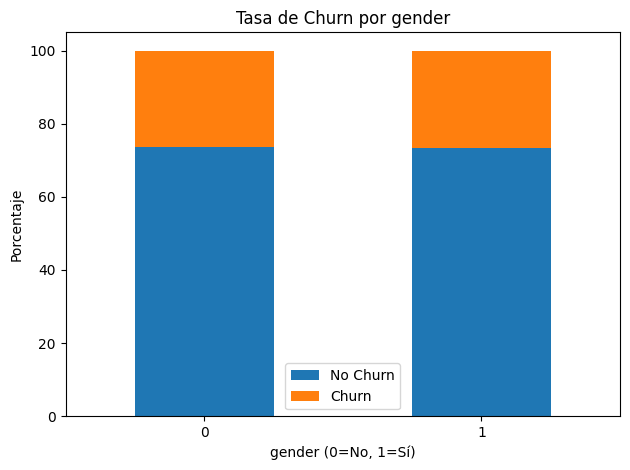


--- Near_Location ---
Porcentaje de Churn por categoría:
Churn                  0          1
Near_Location                      
0              60.258481  39.741519
1              75.894706  24.105294

--- Estadísticas para Near_Location ---
        count      mean       std  min  25%  50%  75%  max
Churn                                                     
0      2939.0  0.873086  0.332933  0.0  1.0  1.0  1.0  1.0
1      1061.0  0.768143  0.422217  0.0  1.0  1.0  1.0  1.0


<Figure size 800x500 with 0 Axes>

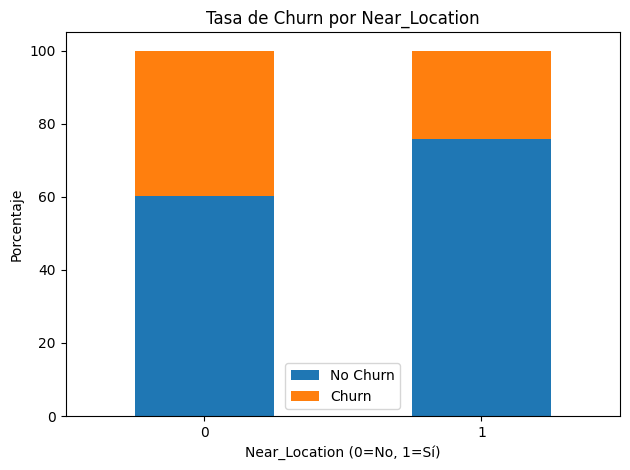


--- Partner ---
Porcentaje de Churn por categoría:
Churn            0          1
Partner                      
0        66.682903  33.317097
1        80.636877  19.363123

--- Estadísticas para Partner ---
        count      mean       std  min  25%  50%  75%  max
Churn                                                     
0      2939.0  0.534195  0.498914  0.0  0.0  1.0  1.0  1.0
1      1061.0  0.355325  0.478837  0.0  0.0  0.0  1.0  1.0


<Figure size 800x500 with 0 Axes>

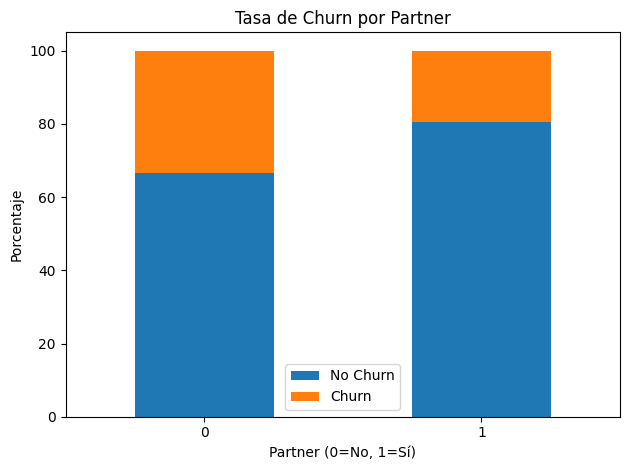


--- Promo_friends ---
Porcentaje de Churn por categoría:
Churn                  0          1
Promo_friends                      
0              68.691251  31.308749
1              84.197731  15.802269

--- Estadísticas para Promo_friends ---
        count      mean       std  min  25%  50%  75%  max
Churn                                                     
0      2939.0  0.353522  0.478144  0.0  0.0  0.0  1.0  1.0
1      1061.0  0.183789  0.387495  0.0  0.0  0.0  0.0  1.0


<Figure size 800x500 with 0 Axes>

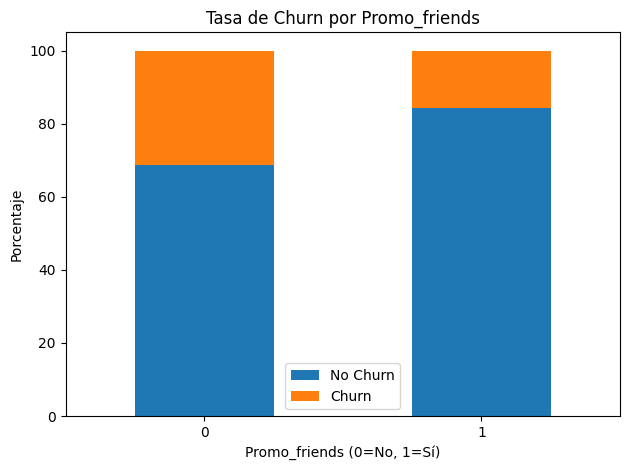


--- Phone ---
Porcentaje de Churn por categoría:
Churn          0          1
Phone                      
0      73.316062  26.683938
1      73.491976  26.508024

--- Estadísticas para Phone ---
        count      mean       std  min  25%  50%  75%  max
Churn                                                     
0      2939.0  0.903709  0.295040  0.0  1.0  1.0  1.0  1.0
1      1061.0  0.902922  0.296204  0.0  1.0  1.0  1.0  1.0


<Figure size 800x500 with 0 Axes>

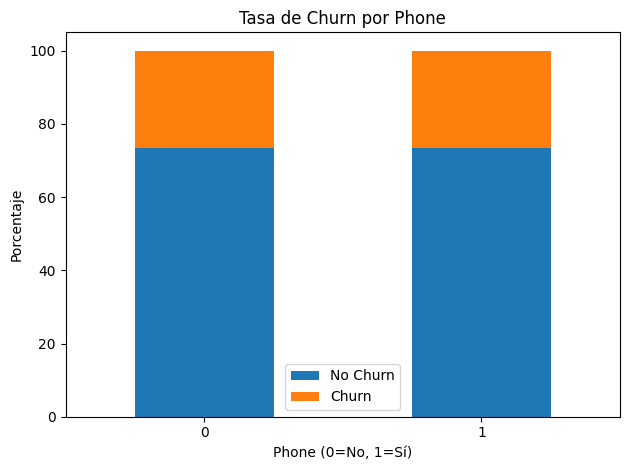


--- Group_visits ---
Porcentaje de Churn por categoría:
Churn                 0          1
Group_visits                      
0             66.992769  33.007231
1             82.716798  17.283202

--- Estadísticas para Group_visits ---
        count      mean       std  min  25%  50%  75%  max
Churn                                                     
0      2939.0  0.464103  0.498795  0.0  0.0  0.0  1.0  1.0
1      1061.0  0.268615  0.443448  0.0  0.0  0.0  1.0  1.0


<Figure size 800x500 with 0 Axes>

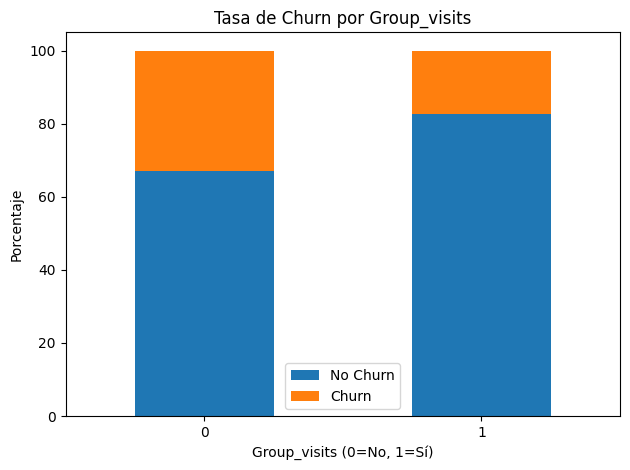

In [121]:
# Para variables binarias (que actúan como categóricas)
binary_cols = ['gender', 'Near_Location', 'Partner', 'Promo_friends', 'Phone', 'Group_visits']

for col in binary_cols:
    contingency_table = pd.crosstab(df_gym[col], df_gym['Churn'], normalize='index') * 100
    print(f"\n--- {col} ---")
    print("Porcentaje de Churn por categoría:")
    print(contingency_table)
    # Estadísticas descriptivas
    print(f"\n--- Estadísticas para {col} ---")
    print(df_gym.groupby('Churn')[col].describe())
    
    # Visualización
    plt.figure(figsize=(8, 5))
    contingency_table.plot(kind='bar', stacked=True)
    plt.title(f'Tasa de Churn por {col}')
    plt.ylabel('Porcentaje')
    plt.xlabel(f'{col} (0=No, 1=Sí)')
    plt.xticks(rotation=0)
    plt.legend(['No Churn', 'Churn'])
    plt.tight_layout()
    plt.show()

<div class="alert alert-block alert-info">
    <b>Comentario añadido:</b> 


Despues de ver las graficas se encuentra que factores si afectan al abandono:
- Gender: Los porcentajes no cambiaron, No hay diferencia
- Near_location: los que abandonan son un 20% menos cuando se vive cerca de las instalaciones.
- Partner: si el usuario trabaja en una compañia asociada a el gimnacio, hay un 14% menos de abanono
- Promo_friends: si el usuario se inscribio mediante una oderta de "trae a un amigo" tiene un 16% menos de abandono.
- Phone: Los porcentajes no cambiaron, no hay diferencia.
- Group_visits: Si el usuario participa en sesiones grupales, hay un 16% menos de abandono.

Con estos datos se puede sacar las conclusiones: 1. gender y phone no brindan informacion. 2. vivir cerca es el factor mas importante a la hora de saber si una persona va abandonar o no. 3. Promo_friend y Group_visits tienen el mismo porcentaje e indica que entre mas sociables sean las personas en el gimnacio, mayor probabilidad de que mantengan la suscripciòn. 4. Partner es el ultimo factor de estudio, pero por su porcentaje cercano a los demas tambien se tendra encuenta en los analisis posteriores.  

<div class="alert alert-block alert-danger">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Cuando presentes gráficas siempre es necesario que dejes en **una celda markdown** una breve interpretación de lo que puedes analizar de las mismas así el proceso de análisis es mucho más claro
</div>

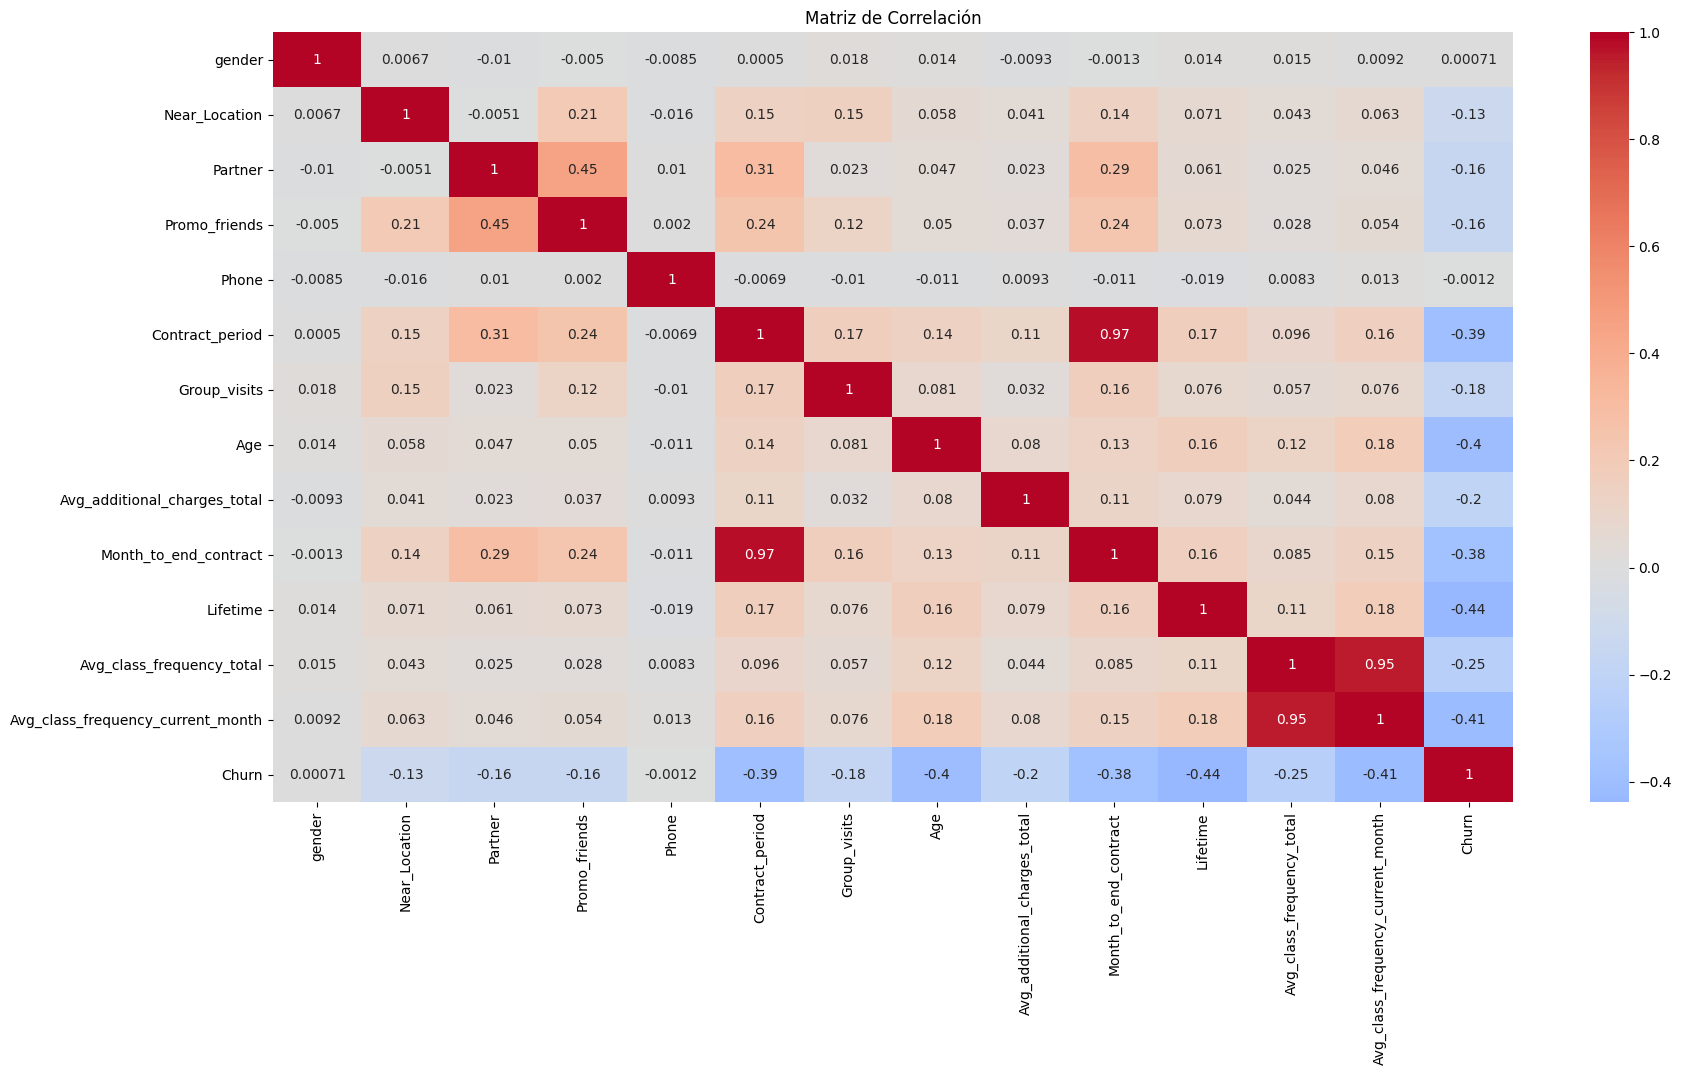


Correlación con Churn:
Churn                                1.000000
gender                               0.000708
Phone                               -0.001177
Near_Location                       -0.128098
Partner                             -0.157986
Promo_friends                       -0.162233
Group_visits                        -0.175325
Avg_additional_charges_total        -0.198697
Avg_class_frequency_total           -0.249715
Month_to_end_contract               -0.381393
Contract_period                     -0.389984
Age                                 -0.404735
Avg_class_frequency_current_month   -0.412348
Lifetime                            -0.438220
Name: Churn, dtype: float64


In [122]:
# Matriz de correlación para variables numéricas
correlation_matrix = df_gym[numeric_cols + ['Churn']].corr()

plt.figure(figsize=(20, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de Correlación')
plt.show()

# Correlación específica con Churn
churn_corr = correlation_matrix['Churn'].sort_values(ascending=False)
print("\nCorrelación con Churn:")
print(churn_corr)

Con estos datos podemos evidenciar de que lo que menos tiene que ver con el avandono de el gimnacio es el tiempo de vida del usuario. A mayor tiempo visitando las instalaciones del gimnacio, menor es el abandono, por otro lado, lo que no tiene relevancia con respecto a el abandono es el genero y si dan el telefono.



<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Muy bien mostrada la matriz de correlación! Solo ten en cuenta que no siempre correlación significa causalidad, puede que en algunos casos tengas variables altamente correlacionadas pero no necesariamente son causa una de la otra

In [123]:
# Crear un resumen ejecutivo de hallazgos
print("="*60)
print("HALLAZGOS PRINCIPALES SOBRE FACTORES DE CHURN")
print("="*60)

# Variables con mayor diferencia
findings = []

for col in numeric_cols:
    churn_yes_mean = df_gym[df_gym['Churn'] == 1][col].mean()
    churn_no_mean = df_gym[df_gym['Churn'] == 0][col].mean()
    diff = churn_yes_mean - churn_no_mean
    findings.append((col, diff, abs(diff)))

# Ordenar por mayor diferencia absoluta
findings.sort(key=lambda x: x[2], reverse=True)

print("\nTop 5 variables numéricas con mayor diferencia:")
for col, diff, abs_diff in findings[:5]:
    print(f"  {col}: Diferencia = {diff:.2f}")



HALLAZGOS PRINCIPALES SOBRE FACTORES DE CHURN

Top 5 variables numéricas con mayor diferencia:
  Avg_additional_charges_total: Diferencia = -43.36
  Contract_period: Diferencia = -4.02
  Lifetime: Diferencia = -3.72
  Month_to_end_contract: Diferencia = -3.62
  Age: Diferencia = -2.99


In [124]:
df_gym = pd.get_dummies(df_gym)
X = df_gym.drop('Churn', axis=1)
y=df_gym['Churn']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2,random_state=0 )

scaler = StandardScaler()
X_train_st = scaler.fit_transform(X_train)

X_test_st = scaler.transform(X_test)

models = [LogisticRegression(),RandomForestClassifier()]

In [125]:
def mape(y_true, y_pred):
    y_error = y_true - y_pred
    y_error_abs = [abs (i) for i in y_error]
    perc_error_abs = y_error_abs/ y_true
    mape = (perc_error_abs.sum()/len(y_true))
    return mape

In [126]:
def predict (m, X_train, y_train, X_test, y_test):
    model = m
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print('MAE:{:.2f} MSE:{:.2f} MAPE:{:.2f} R2:{:.2f} '.format(mean_absolute_error(y_test, y_pred), 
                                          mean_squared_error(y_test, y_pred),
                                                                    mape(y_test, y_pred),
                                                                    r2_score(y_test, y_pred)))

In [127]:
for i in models:
    print(i),
    predict(m=i, X_train = X_train_st, y_train=y_train, X_test=X_test_st, y_test= y_test)

LogisticRegression()
MAE:0.08 MSE:0.08 MAPE:inf R2:0.58 
RandomForestClassifier()
MAE:0.09 MSE:0.09 MAPE:inf R2:0.53 


Con las presentes metricas se puede escoger el modelo de regresion logistica, aunque la diferencia con el bosque aleatorio es apenas de 0.03

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Muy buen trabajo! Obtuviste resultados muy buenos en el entrenamiento de tus modelos y realizaste el análisis adecuado a partir de los mismos
</div>

In [128]:
features_for_clustering = df_gym.drop('Churn', axis=1)

In [129]:
features_for_clustering = pd.get_dummies(features_for_clustering)

In [130]:
scaler_cluster = StandardScaler()
features_scaled = scaler_cluster.fit_transform(features_for_clustering)

In [131]:
linked = linkage(features_scaled, method='ward')

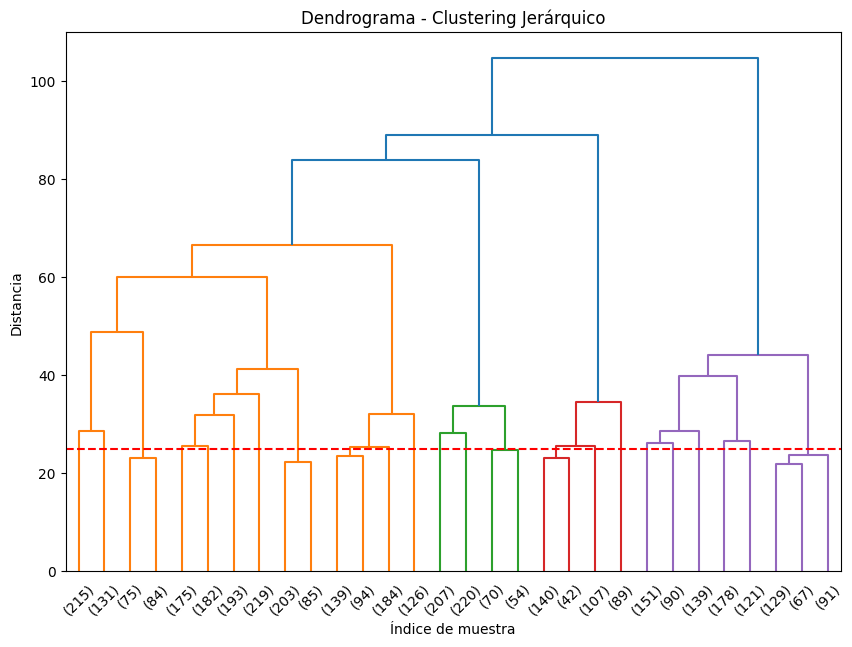

In [132]:

plt.figure(figsize=(10, 7))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True,
           truncate_mode='lastp',
           p=30)
plt.title('Dendrograma - Clustering Jerárquico')
plt.xlabel('Índice de muestra')
plt.ylabel('Distancia')
plt.axhline(y=25, color='r', linestyle='--')  # Línea para cortar clusters
plt.show()


El cluster jerarquico indica que el numero apropiado son 3 clusters.
La linea roja esta trazada antes de un salto grande entre niveles.

In [133]:
num_clusters_hierarchical = 3
hierarchical_clusters = fcluster(linked, num_clusters_hierarchical, criterion='maxclust')


=== K-MEANS CLUSTERING ===


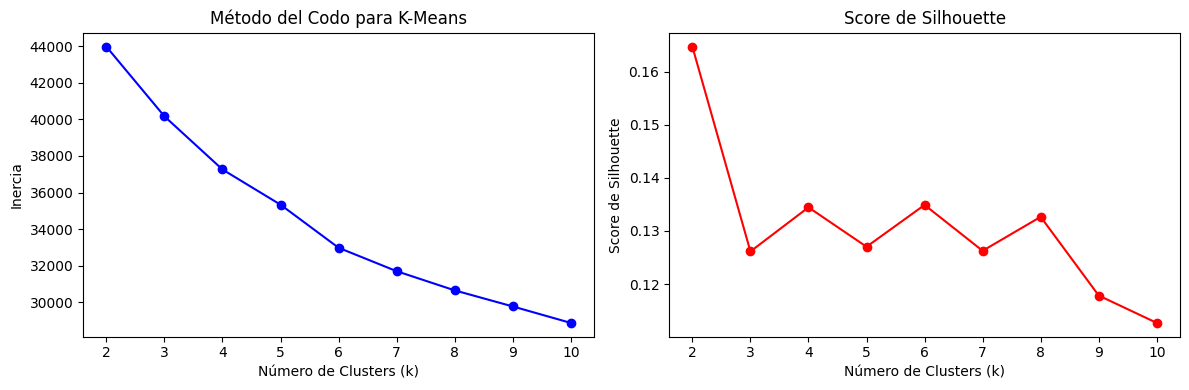

Número óptimo de clusters sugerido: 2


In [134]:
print("\n=== K-MEANS CLUSTERING ===")

# Método del codo para determinar número óptimo de clusters
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(features_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(features_scaled, kmeans.labels_))

# Graficar método del codo
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(K_range, inertia, 'bo-')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del Codo para K-Means')

plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, 'ro-')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Score de Silhouette')
plt.title('Score de Silhouette')

plt.tight_layout()
plt.show()

# Determinar número óptimo de clusters (usualmente donde la curva deja de descender significativamente [codo])
optimal_k1 = silhouette_scores.index(max(silhouette_scores)) + 2
print(f"Número óptimo de clusters sugerido: {optimal_k1}")

# Aplicar K-Means con número óptimo de clusters
kmeans1 = KMeans(n_clusters=optimal_k1, random_state=42, n_init=10)
kmeans_clusters1 = kmeans1.fit_predict(features_scaled)


el grafico de k-means muestra que el numero optimo de clusteres es 5. Mientras que en el score de silhousette informa que el numero optimo es 2 clusters. 

In [135]:
#aplicando indicaciones del enunciado:
optimal_k2 = 5

kmeans2 = KMeans(n_clusters=optimal_k2, random_state=42, n_init=10)
kmeans_clusters2 = kmeans2.fit_predict(features_scaled)

In [136]:
# --- Análisis de resultados ---
print("\n=== ANÁLISIS DE CLUSTERS ===")

# Añadir clusters al DataFrame original
df_gym['Cluster_KMeans_1'] = kmeans_clusters1
df_gym['Cluster_Hierarchical_1'] = hierarchical_clusters


# Añadir clusters al DataFrame original 2
df_gym['Cluster_KMeans_2'] = kmeans_clusters2
df_gym['Cluster_Hierarchical_2'] = hierarchical_clusters


# Analizar características de cada cluster (K-Means)
print("\nCaracterísticas promedio por cluster (K-Means- K1):")
for cluster_num in range(optimal_k1):
    cluster_data = df_gym[df_gym['Cluster_KMeans_1'] == cluster_num]
    print(f"\nCluster {cluster_num} - {len(cluster_data)} usuarios:")

    
    # Mostrar características promedio para las columnas numéricas originales
    numeric_cols = df_gym.select_dtypes(include=[np.number]).columns
    numeric_cols = [col for col in numeric_cols if 'Churn' not in col and 'Cluster' not in col]
    
    if len(numeric_cols) > 0:
        print("Promedios:")
        for col in numeric_cols[:5]:  
            print(f"  {col}: {cluster_data[col].mean():.2f}")

print("="*60)
print("\nCaracterísticas promedio por cluster (K-Means- K2):")

for cluster_num in range(optimal_k2):
    cluster_data = df_gym[df_gym['Cluster_KMeans_2'] == cluster_num]
    print(f"\nCluster {cluster_num} - {len(cluster_data)} usuarios:")
    # Mostrar características promedio para las columnas numéricas originales
    numeric_cols = df_gym.select_dtypes(include=[np.number]).columns
    numeric_cols = [col for col in numeric_cols if 'Churn' not in col and 'Cluster' not in col]
    
    if len(numeric_cols) > 0:
        print("Promedios:")
        for col in numeric_cols[:5]:  
            print(f"  {col}: {cluster_data[col].mean():.2f}")
    


=== ANÁLISIS DE CLUSTERS ===

Características promedio por cluster (K-Means- K1):

Cluster 0 - 2537 usuarios:
Promedios:
  gender: 0.51
  Near_Location: 0.79
  Partner: 0.34
  Promo_friends: 0.18
  Phone: 0.91

Cluster 1 - 1463 usuarios:
Promedios:
  gender: 0.52
  Near_Location: 0.94
  Partner: 0.74
  Promo_friends: 0.53
  Phone: 0.90

Características promedio por cluster (K-Means- K2):

Cluster 0 - 633 usuarios:
Promedios:
  gender: 0.50
  Near_Location: 0.95
  Partner: 0.83
  Promo_friends: 1.00
  Phone: 1.00

Cluster 1 - 889 usuarios:
Promedios:
  gender: 0.55
  Near_Location: 0.85
  Partner: 0.26
  Promo_friends: 0.05
  Phone: 1.00

Cluster 2 - 865 usuarios:
Promedios:
  gender: 0.50
  Near_Location: 0.94
  Partner: 0.74
  Promo_friends: 0.48
  Phone: 1.00

Cluster 3 - 1227 usuarios:
Promedios:
  gender: 0.49
  Near_Location: 0.72
  Partner: 0.30
  Promo_friends: 0.02
  Phone: 1.00

Cluster 4 - 386 usuarios:
Promedios:
  gender: 0.52
  Near_Location: 0.86
  Partner: 0.47
  Promo_

Comparando los promeidios del inicio con los promedios de los dos clusteres y luego con los de 5, se encuentra dos datos que no tienen un gradiente grande, que son el genero y el telefono. Vivir cerca es un indicador positivo de que no haya abandono. Por otro lado, partner tiene una variacion favorable en el modelo de dos clusters(0.74), pero algo desfavorable en el modelo de 5 clusters(dos de los datos estan por debajo, los otros tres datos estan por encima). por ultimo estan la promocion de amigos, que en el odelo de 2 clusters es favorable, pero en el de 5 clusters hay dos donde es muy desfavorable. 

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Bien hecho! Se nota claramente la segmentación entre los diferentes grupos ya que tienen un churn rate diferente
</div>


=== VISUALIZACIÓN CON PCA ===


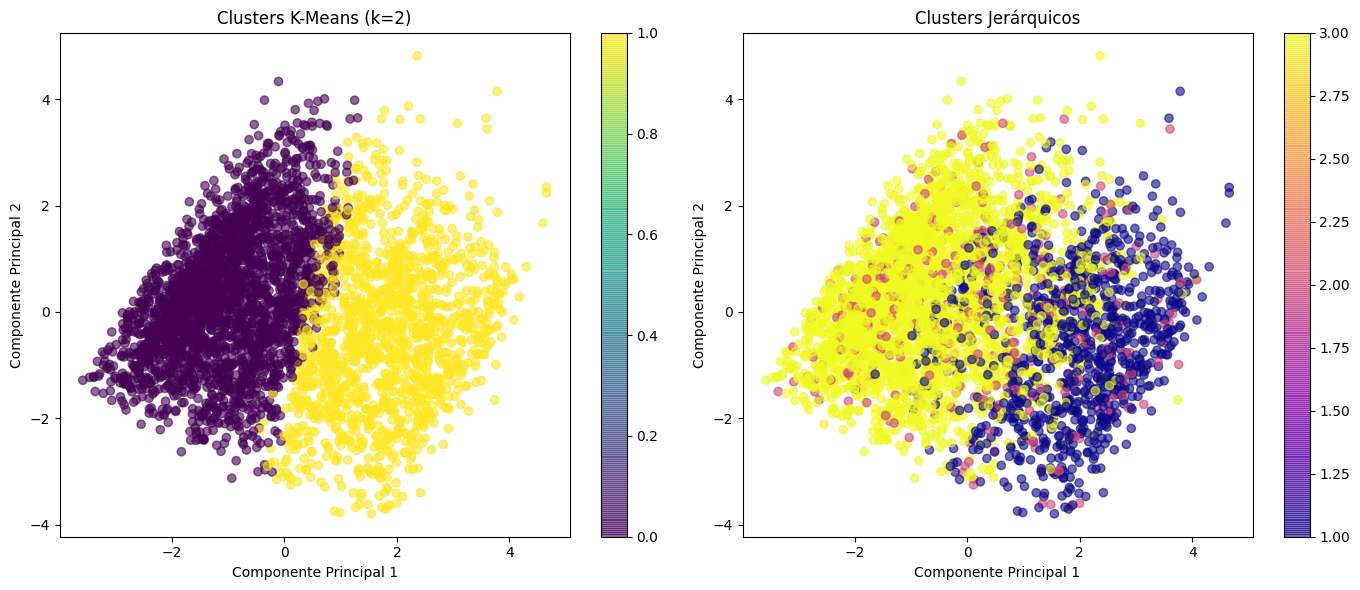

In [137]:

# --- Visualización de clusters con PCA ---
print("\n=== VISUALIZACIÓN CON PCA ===")

# Reducir dimensionalidad para visualización
pca = PCA(n_components=2)
features_pca = pca.fit_transform(features_scaled)

# Visualizar clusters K-Means
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
scatter = plt.scatter(features_pca[:, 0], features_pca[:, 1], 
                     c=kmeans_clusters1, cmap='viridis', alpha=0.6)
plt.colorbar(scatter)
plt.title(f'Clusters K-Means (k={optimal_k1})')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')

# Visualizar clusters jerárquicos
plt.subplot(1, 2, 2)
scatter = plt.scatter(features_pca[:, 0], features_pca[:, 1], 
                     c=hierarchical_clusters, cmap='plasma', alpha=0.6)
plt.colorbar(scatter)
plt.title('Clusters Jerárquicos')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')

plt.tight_layout()
plt.show()



=== VISUALIZACIÓN CON PCA ===


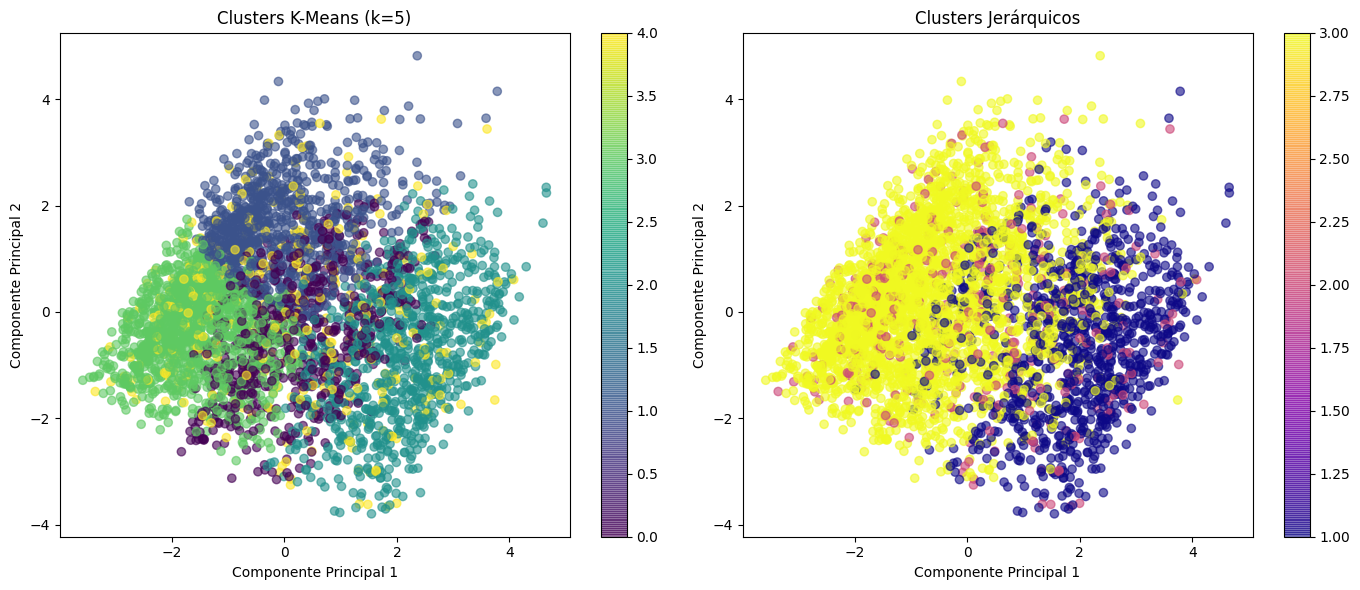

In [138]:
# --- Visualización de clusters con PCA ---
print("\n=== VISUALIZACIÓN CON PCA ===")

# Reducir dimensionalidad para visualización
pca = PCA(n_components=5)
features_pca = pca.fit_transform(features_scaled)

# Visualizar clusters K-Means
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
scatter = plt.scatter(features_pca[:, 0], features_pca[:, 1], 
                     c=kmeans_clusters2, cmap='viridis', alpha=0.6)
plt.colorbar(scatter)
plt.title(f'Clusters K-Means (k={optimal_k2})')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')

# Visualizar clusters jerárquicos
plt.subplot(1, 2, 2)
scatter = plt.scatter(features_pca[:, 0], features_pca[:, 1], 
                     c=hierarchical_clusters, cmap='plasma', alpha=0.6)
plt.colorbar(scatter)
plt.title('Clusters Jerárquicos')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')

plt.tight_layout()
plt.show()

La cantidad de clusters importa mucho, pues a mas clusteres mas complejo segmentar y aplicar estrategias, en los cuatro graficos anteriores se puede ver como en el de 2 clusters los grupos si estan bien definidos uno del otro, sin embargo, en el de 5, aunque se nota una diferencia, no se distinguen fronteras las cuales usar para aplicar las estrategias.

In [139]:

print("\n=== INTEGRACIÓN CON MODELOS DE PREDICCIÓN ===")

# Puedes usar los clusters como una característica adicional para tus modelos con k=2
users_with_clusters1 = pd.get_dummies(df_gym.drop(['Cluster_KMeans_1', 'Cluster_Hierarchical_1'], axis=1))
users_with_clusters1['Cluster_KMeans_1'] = kmeans_clusters1
users_with_clusters1['Cluster_Hierarchical_1'] = hierarchical_clusters

# Ahora divides tus datos como antes, pero con clusters incluidos
X_with_clusters1 = users_with_clusters1.drop('Churn', axis=1)
y_with_clusters1 = users_with_clusters1['Churn']

# Divide en entrenamiento y prueba
X_train_cl1, X_test_cl1, y_train_cl1, y_test_cl1 = train_test_split(
    X_with_clusters1, y_with_clusters1, test_size=0.2, random_state=42
)

# Estandarizar
scaler_full1 = StandardScaler()
X_train_cl_st1 = scaler_full1.fit_transform(X_train_cl1)
X_test_cl_st1 = scaler_full1.transform(X_test_cl1)

print(f"Dimensiones con clusters añadidos: {X_train_cl_st1.shape}")




=== INTEGRACIÓN CON MODELOS DE PREDICCIÓN ===
Dimensiones con clusters añadidos: (3200, 17)


<div class="alert alert-block alert-info">
    <b>Resuelto lo de la variable:</b> 
 X_with_clusters era X_with_clusters1

<div class="alert alert-block alert-danger">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Esta celda no se puede ejecutar ya que la variable `X_with_clusters` no ha sido definida. Para que puedas identificar este tipo de errores, sobre todo cuando estés trabajando en equipo, antes de compartir tu notebook siempre reinicia el kernel y ejecuta todo desde cero ya que a veces se suelen quedar en la memoria del kernel variables que fueron borradas en alguna celda.
</div>

In [140]:
print("\n=== INTEGRACIÓN CON MODELOS DE PREDICCIÓN ===")

# Puedes usar los clusters como una característica adicional para tus modelos con k=2
users_with_clusters2 = pd.get_dummies(df_gym.drop(['Cluster_KMeans_2', 'Cluster_Hierarchical_2'], axis=1))
users_with_clusters2['Cluster_KMeans_2'] = kmeans_clusters2
users_with_clusters2['Cluster_Hierarchical_2'] = hierarchical_clusters

# Ahora divides tus datos como antes, pero con clusters incluidos
X_with_clusters2 = users_with_clusters2.drop('Churn', axis=1)
y_with_clusters2 = users_with_clusters2['Churn']

# Divide en entrenamiento y prueba
X_train_cl2, X_test_cl2, y_train_cl2, y_test_cl2 = train_test_split(
    X_with_clusters2, y_with_clusters2, test_size=0.2, random_state=42
)

# Estandarizar
scaler_full2 = StandardScaler()
X_train_cl_st2 = scaler_full2.fit_transform(X_train_cl2)
X_test_cl_st2 = scaler_full2.transform(X_test_cl2)

print(f"Dimensiones con clusters añadidos: {X_train_cl_st2.shape}")



=== INTEGRACIÓN CON MODELOS DE PREDICCIÓN ===
Dimensiones con clusters añadidos: (3200, 17)


Aunque sean 2 o 5 clusters el tamaño y las dimensiones terminaron siendo iguales.


In [141]:
# Calcular tasa de cancelación por cluster (K-Means k=2)
churn_rate_k2 = df_gym.groupby('Cluster_KMeans_1')['Churn'].agg(['count', 'sum', 'mean'])
churn_rate_k2.columns = ['Total_Clientes', 'Clientes_Abandonaron', 'Tasa_Cancelacion']
churn_rate_k2['Tasa_Cancelacion_Porcentaje'] = churn_rate_k2['Tasa_Cancelacion'] * 100

print("=== TASA DE CANCELACIÓN POR CLUSTER (K=2) ===")
print(churn_rate_k2)

=== TASA DE CANCELACIÓN POR CLUSTER (K=2) ===
                  Total_Clientes  Clientes_Abandonaron  Tasa_Cancelacion  \
Cluster_KMeans_1                                                           
0                           2537                  1013          0.399291   
1                           1463                    48          0.032809   

                  Tasa_Cancelacion_Porcentaje  
Cluster_KMeans_1                               
0                                    39.92905  
1                                     3.28093  


In [142]:
# Calcular tasa de cancelación por cluster (K-Means k=2)
churn_rate_k5 = df_gym.groupby('Cluster_KMeans_2')['Churn'].agg(['count', 'sum', 'mean'])
churn_rate_k5.columns = ['Total_Clientes', 'Clientes_Abandonaron', 'Tasa_Cancelacion']
churn_rate_k5['Tasa_Cancelacion_Porcentaje'] = churn_rate_k5['Tasa_Cancelacion'] * 100

print("=== TASA DE CANCELACIÓN POR CLUSTER (K=5) ===")
print(churn_rate_k5)

=== TASA DE CANCELACIÓN POR CLUSTER (K=5) ===
                  Total_Clientes  Clientes_Abandonaron  Tasa_Cancelacion  \
Cluster_KMeans_2                                                           
0                            633                   156          0.246445   
1                            889                    80          0.089989   
2                            865                    19          0.021965   
3                           1227                   703          0.572942   
4                            386                   103          0.266839   

                  Tasa_Cancelacion_Porcentaje  
Cluster_KMeans_2                               
0                                   24.644550  
1                                    8.998875  
2                                    2.196532  
3                                   57.294214  
4                                   26.683938  


En el modelo de los 2 clusters, el cluster numero 0 fue el que mayor tasa de cancelacion tuvo.

En el modelo de los 5 clusters el tercer grupo fue el de mayor cancelacion, luego el grupo 4, de terceras y no por mucho, esta el grupo 0 y despues el grupo 1 y 2, qu son los que menor cancelacion tienen.

En ambos casos hay que analizar los grupos de abandono y conocer las razones del abandono. 

Para el grupo 3 se puede realizar una trazabilidad para conocer que los llevo a dejar el gimnacio, en los grupos 4 y 0 se les puede ofrecer clases y consumos con descuento para que aumenten la frecuencia del uso del gimnacio y, si le agarran el amor por hacer ejercicio, fidelizar a los usuarios. Para los grupos 1 y 2 se les puede planear un programa de fidelización con el objetivo de que cada vez se sientan mas a gusto en el gimnacio y que lo sigan frecuentando e incluso traigan a amigos y familiares. 

Tambien hay que tener encuenta que los usuarios que cada vez gastan menos en los demas servicios del gimnacio y su contrato esta por llegar a termino, es mas probable que abandone el gimnacio. a estos usuarios hay que brindarles incentivos para que sigan usando las instalaciones, pero los incentivos no pueden ser de alto costo, todo lo contrario, han de ser de bajo costo para el gimnacio, pues son clientes que no necesariamente van a traer ganancias exponenciales. 

Por el contrario, a los usuarios que iniciaron el contrato y estan gastando una suma muy valorable en servicios adicionales del gimnacio, hay que incenivarlos a que traigan a sus amigos, pareja y demas, pues estos pueden incrementar las ganancias del gimnacio y recomendar las instalaciones, productos y servicis

Tambien hay que incentivar a los que viven cerca a continuar asistiendo al gimnacio.

Por otro lado, como se evidencia arriba, si las personas socializan en el gimnacio, sea por asistencia a el gimnacion con un amigo o por la asistencia a las seciones grupales, hay una menor tasa de abandono. Como empresa no podemos entrar en la subjetividad de lazos fraternales de las personas, pero si realizar promociones e incentivos para que se asista con amigos, en grupo o incremntar las sesiones grupales en horarios donde haya mas flujo de personas, o inclso viceversa, para mantener o incrementar la media de asistencia en las instalaciones. 

<div class="alert alert-block alert-success">
<b>Comentario general (2da Iteracion)</b> <a class=“tocSkip”></a>

Muy buen trabajo, manejaste muy bien los datos previo al entrenamiento de tus modelos y analizaste muy bien los resultados.
    
Planteaste muy buenas conclusiones en base a los datos de tu análisis, un buen análisis siempre debe venir acompañado de recomendaciones que ayuden a la toma de decisiones que en este caso haz planteado sugerencias muy buenas en cuanto a los diferentes tipos de usuarios obtenidos.
    
    
Saludos!
</div>